# Model experiment  

Try GAT and GCN implementation 

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, Dropout
from torch_geometric.nn import GCNConv, GATv2Conv
from torchviz import make_dot
# Define data loader
import sys
import gc
sys.path.append('../')
from model.data_loader import PEFDataset,fetch_dataloader
from model.data_loader import params as data_params
from model.model_cfg import CFG
from model.hydro_net import PEM

from tqdm import tqdm

In [6]:
def criterion(E,X_native,X_decoy,model,N,h):
    """
    The loss function for the model coressponds to 3 main losses:
    1. lossg: the partial derivateve of the energy with respect to the native structure
    2. lossd: the energy of the native structure divided by the decoy energy
    3. lossc: After preforming an iterative optimization on the decoy structure, by using the energy partial derivative on the decoy structure, 
              we calculate the dRMSD of the end and the start of the optimization.

    Args:
        E (tensor): A tensor containing the energy of the native and the decoy structure Exd,Exn [2]
        X_native (tensor): A tensor containing the native structure [batch_size,seq_len,4,3]
        X_decoy (tensor): A tensor containing the decoy structure [batch_size,seq_len,4,3]
        model (torch.model): model that was trained
        N (int): The number of iterations for the iterative optimization
        h (float): The step size for the numerical derivative
    output:
        loss (tensor): The loss of the model
    """
    # print('***Start criterion function***')
    # partial_dx_decoy = torch.autograd.grad(E[:,0].sum(),model.parameters(),create_graph=True,allow_unused=True)
    partial_dx_native = torch.autograd.grad(E[1].sum(),model.parameters(),create_graph=True,allow_unused=True)
    # print('***End derivative calc function***')
    
    part_dx_native = [ 0 if part_dx is None else torch.norm(part_dx,p=2) for part_dx in partial_dx_native]
    lossg = sum(part_dx_native)
    
    lossd = (E[1] / E[0]).mean()
    
    # lossc = preform_energy_optimization(X_decoy,partial_dx_decoy)
    # print(f"loss g: {round(lossg.item(),4)} loss d: {round(lossd.item(),4)}")
    return lossd+lossg

In [28]:
class GCN(torch.nn.Module):
  """Graph Convolutional Network"""
  def __init__(self, dim_in, dim_h, dim_out):
    super().__init__()
    self.gcn1 = GCNConv(dim_in, dim_h)
    self.gcn2 = GCNConv(dim_h, dim_out)
    self.optimizer = torch.optim.Adam(self.parameters(),
                                      lr=0.01,
                                      weight_decay=5e-4)

  def forward(self, x, edge_index):
    h = F.dropout(x, p=0.5, training=self.training)
    h = self.gcn1(h, edge_index)
    h = torch.relu(h)
    h = F.dropout(h, p=0.5, training=self.training)
    h = self.gcn2(h, edge_index)
    return h, F.log_softmax(h, dim=1)


class GAT(torch.nn.Module):
  
  """Graph Attention Network"""
  def __init__(self, dim_in, dim_h, dim_out, heads=8):
    super().__init__()
    self.gat1 = GATv2Conv(dim_in, dim_h, heads=heads)
    self.gat2 = GATv2Conv(dim_h*heads, dim_out, heads=1)
    self.optimizer = torch.optim.Adam(self.parameters(),
                                      lr=0.005,
                                      weight_decay=5e-4)

  def forward(self, x, edge_index):
    h = F.dropout(x, p=0.6, training=self.training)
    h = self.gat1(x, edge_index)
    h = F.elu(h)
    h = F.dropout(h, p=0.6, training=self.training)
    h = self.gat2(h, edge_index)
    return h, F.log_softmax(h, dim=1)

class PEM(torch.nn.Module):
  """Protein energy model"""
  
  def __init__(self, dim_in, dim_h, dim_out, layers, model_type, heads = 8):
    super().__init__()
    
    if model_type == 'GCN':
      self.model = [GCN(dim_in, dim_h, dim_out) for i in range(layers)]
    elif model_type == 'GAT':
      # # self.model = [GAT(dim_in, dim_h, dim_out) for i in range(layers)]
      # self.gat1 = GATv2Conv(dim_in, dim_h, heads=heads)
      # self.gat2 = GATv2Conv(dim_h*heads, dim_out, heads=1)
      # self.optimizer = torch.optim.Adam(self.parameters(),
      #                                   lr=0.005,
      #                                   weight_decay=5e-4)
      self.model =[GAT(dim_in, dim_h, dim_out, heads) for i in range(layers)]
    else:
      raise ValueError('Model type not supported')
    self.layers = layers
    # First fully connected layer
    self.fcs1 = nn.Linear(36, 128)
    self.fcs2 = nn.Linear(128, 36)
    self.bn1  = nn.BatchNorm1d(36)
    # First fully connected layer
    self.fc1 = nn.Linear(36, 128)
    # Second fully connected layer that outputs our 10 labels
    self.fc2 = nn.Linear(128, 1)
  
  def forward(self,x_decoy, emb_decoy,x_native,emb_native ,edge_index):
      x_decoy  = self.get_graph(x_decoy, emb_decoy)
      identity = x_decoy
      x = x_decoy
      x = self.fcs1(x)
      x = F.relu(x)
      x = self.fcs2(x)
      x = self.bn1(x)
      for layer in range(self.layers):
        # h = F.dropout(x, p=0.6, training=self.training)
        # h = self.gat1(x, edge_index)
        # h = F.elu(h)
        # h = F.dropout(h, p=0.6, training=self.training)
        # h = self.gat2(h, edge_index)
        
        # h = F.log_softmax(h, dim=1)+identity
        h1,x = self.model[layer](x, edge_index) 
        x = x + identity
      
      x  = self.fc1(x)
      x = F.relu(x)
      x_decoy = self.fc2(x)

      
      x_native  = self.get_graph(x_native, emb_native)
      identity = x_native
      x = x_native
      x = self.fcs1(x)
      x = F.relu(x)
      x = self.fcs2(x)
      x = self.bn1(x)
      for layer in range(self.layers):
        # h = F.dropout(x, p=0.6, training=self.training)
        # h = self.gat1(x, edge_index)
        # h = F.elu(h)
        # h = F.dropout(h, p=0.6, training=self.training)
        # h = self.gat2(h, edge_index)
        
        # h = F.log_softmax(h, dim=1)+identity
        h1,x = self.model[layer](x, edge_index) 
        x = x + identity
      
      x  = self.fc1(x)
      x = F.relu(x)
      x_native = self.fc2(x)
    
      
     
      return torch.cat((self.get_energy(x_decoy).unsqueeze(0), self.get_energy(x_native).unsqueeze(0)),dim=0)
    
  def get_graph(self,x, emb):
    """Get graph representation of protein"""
    D = self.get_dist_matrix(x) # N,N,16
    D = torch.relu(torch.exp(-1e1*D))
    
    D = D.sum(dim=1) #N,16
    
    Fh = torch.cat([emb,D],dim=1) #N,16+emb_size
    
    return Fh
  
  def get_dist_matrix(self,Xd):
      """
      Return the node distence matrix
      Args:
          Xd (tensor):X embeded [n_nodes ,num_atoms=4,new_cords_size]
      Returns:
          tensor : [n_nodes,n_nodes ,atom_dist=16] tensor
      """
      N_residu,N_atoms,coords_size = Xd.shape
      Xd = Xd.reshape(N_residu*N_atoms,coords_size)
      D = torch.cdist(Xd,Xd,p=2)
      D = D.reshape(N_residu,N_atoms,N_residu,N_atoms)
      D = torch.swapaxes(D,2,3)
      D = D.reshape(N_residu,N_residu,N_atoms*N_atoms)
      return D
  
  def get_energy(self,Fh):
        """
        Calculates the energy of the protein
        Inputs:
            Fh: a [n_nodes , embedding_size+N_residu] tensor
        Returns:
            Energy [batch_size] tensor
        """
        E = torch.sum(Fh**2,dim=(0,1))
        return E

In [29]:
# define one epoch train
def training (model, optimizer, dataloader, device,N):
    """
    Training function for the model.
    Args:
        model (torch.model): model to train
        optimizer (torch.optim): optimizer to use
        dataloader (torch.utils.data.DataLoader): dataloader for the training set
        device (torch.device): device to use ('cpu' or 'cuda' or 'mps')
        N (int): The number of iterations for the iterative optimization
    """
    model.train()
    
    for epoch in range(CFG.num_epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        torch.cuda.empty_cache()
        gc.collect()
        with tqdm(dataloader, unit="batch") as tepoch:
            for i, data in enumerate(tepoch):
                # set progress bar description
                tepoch.set_description(f"Epoch {epoch}")
                # Clean the GPU cache
                torch.cuda.empty_cache()
                gc.collect()
                # get the inputs; data is a list of [inputs, labels]   
                seq_one_hot,seq_decoy ,id, Xd,Xn, mask, nativemask, esm_embed = data
                Xd = Xd.to(device)
                Xn = Xn.to(device)
                esm_embed = esm_embed.to(device)
                seq_one_hot = seq_one_hot.to(device) # [batch_size,20,seq_len]
                seq_one_hot = torch.swapaxes(seq_one_hot,1,2) # swap the axes to [batch_size,seq_len,20]
                seq_decoy = torch.swapaxes(seq_decoy,1,2)
                #emb = torch.cat((esm_embed,seq),dim=2)
                emb = seq_one_hot
                emb_decoy = seq_decoy.to(device)
                # zero the parameter gradients
                optimizer.zero_grad()
                Xd = Xd.squeeze()
                Xn = Xn.squeeze()
                # Xd = Xd.reshape(Xd.shape[0],-1)
                emb_decoy = emb_decoy.squeeze()
                emb = emb.squeeze()
                
                # Xd_features = torch.cat((Xd,emb_decoy),dim=1)
                # create edge_index
                edge_index = torch.tensor([],dtype=torch.long)
                # forward + backward + optimize
                for i in range(Xd.shape[0]):
                    for j in range(i,Xd.shape[0]):
                        if i == j:
                            continue
                        else:
                            edge_index = torch.cat((edge_index,torch.tensor([[i,j]],dtype=torch.long)),dim=0) 
                edge_index = edge_index.to(device)
                
                outputs = model(Xd,emb_decoy,Xn,emb,edge_index.t().contiguous())
                
                loss = criterion(outputs,Xd,Xn,model,N,CFG.h)
               
                loss.backward()
                # print_par(model) # print the parameters of the model
                optimizer.step()

                # print statistics
                running_loss += loss.item()
                if i % 2000 == 1999:    # print every 2000 mini-batches
                    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
                    running_loss = 0.0
                
                torch.cuda.empty_cache()
                gc.collect()
                # update the progress bar
                tepoch.set_postfix(loss=round(loss.item(),3))
                # save the model
                # 
                # save_checkpoint(epoch, model, optimizer,loss,CFG.model_path)
    print('Finished Training')

In [30]:
# fetch data
print('***load the data with dataloader***')
d_params = data_params(num_workers =CFG.num_workers, batch_size=CFG.batch_size,cuda=CFG.cuda,debug=True,constraint=CFG.constraint)
train_loader, valid_loader,test_loader = fetch_dataloader(data_dir='.'+CFG.data_path, params=d_params)


***load the data with dataloader***
Checking data constraint...


100%|██████████| 80/80 [00:02<00:00, 33.50it/s]


Checking data constraint...


100%|██████████| 10/10 [00:00<00:00, 26.74it/s]


Checking data constraint...


100%|██████████| 10/10 [00:00<00:00, 48.59it/s]


In [7]:
model = PEM(dim_in=36,dim_h=64,dim_out=36,layers=CFG.num_layers,gaussian_coef=CFG.gaussian_coef).to(CFG.device)
# Count the number of parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of parameters: {num_params}")    

Number of parameters: 96021


In [32]:
# Run training
print('***Start training***')
torch.autograd.set_detect_anomaly(False)
training(model, optimizer, train_loader, device,CFG.N)

***Start training***


Epoch 0:  28%|██▊       | 5/18 [00:38<01:41,  7.78s/batch, loss=2.07e+6]


KeyboardInterrupt: 

In [ ]:
a = torch.tensor(1.0)
a = a.unsqueeze(0)
b = torch.clone(a)
torch.cat((a,b),dim=0).shape

torch.Size([2])

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm   # For progress bar

# Define the neural network
class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()
        self.fc1 = nn.Linear(1, 10)
        self.fc2 = nn.Linear(10, 3)
        self.fc3 = nn.Linear(3, 1)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x =torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x



def energy(x):
    return x**2

def get_sample(n):
    beta = 1/0.001
    x = torch.rand(n)*20 -10
    y = torch.exp(-beta*energy(x))
    z = torch.rand(n)
    i = (y - z)>0
    return x[i]
# a = sample(10000)
# print(a.shape)
# # print(a)
# print(torch.max(a))
# print(torch.min(a))

# plt.hist(a.detach().numpy(),bins=5)
# plt.show()
# Create an input tensor
# input_tensor = torch.randn((20, 4, 3), requires_grad=True)



# # Pass the input through the network
# output = net(input_tensor)

# Define the score matching loss function
def score_matching_loss(output,input,input_noise):
    input_grad = torch.autograd.grad(outputs=output, inputs=input, grad_outputs=torch.ones_like(output), create_graph=True)[0]
    # loss = torch.mean(torch.sum(input_grad**2))
    loss = 0.5* torch.norm(input_grad-input_noise,p=2)**2
    return loss

# set progess bar
# tepoch = tqdm(range(1000000))
# for epoch in tepoch:
#     # Create an input tensor
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Create an instance of the network
net = MyNet().to(device)
samples = get_sample(1000000)
print("sample shape:",samples.shape)
for epoch in range(20):
    running_loss = 0.0
    with tqdm(samples, unit="batch") as tepoch:
        for i, sample in enumerate(tepoch):
            # set progress bar description
            tepoch.set_description(f"Epoch {epoch}")
            tepoch.set_postfix(loss=round(loss.item(),3))
            sample = sample.to(device)
            input_tensor = torch.tensor(sample.unsqueeze(0), requires_grad=True).to(device)
            input_noise = torch.randn(1, requires_grad=True).to(device)
            input_tensor = input_tensor + input_noise
            
            # Pass the input through the network
            output = net(input_tensor)
            # Compute the score matching loss
            loss = score_matching_loss(output,input_tensor,input_noise)

            # print("Loss:", loss.item())
            running_loss += loss.item()
            # Perform backpropagation and update the network's parameters
            optimizer = optim.SGD(net.parameters(), lr=0.01)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            torch.cuda.empty_cache()
        print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')


sample shape: torch.Size([2844])


Epoch 0: 100%|██████████| 2844/2844 [00:08<00:00, 341.76batch/s, loss=0.081]


[1,  2844] loss: 0.138


Epoch 1: 100%|██████████| 2844/2844 [00:08<00:00, 327.04batch/s, loss=0]    


[2,  2844] loss: 0.088


...

[18,  2844] loss: 0.092


Epoch 18: 100%|██████████| 2844/2844 [00:07<00:00, 368.65batch/s, loss=0.017]


[19,  2844] loss: 0.086


Epoch 19: 100%|██████████| 2844/2844 [00:09<00:00, 299.61batch/s, loss=0.009]

[20,  2844] loss: 0.090


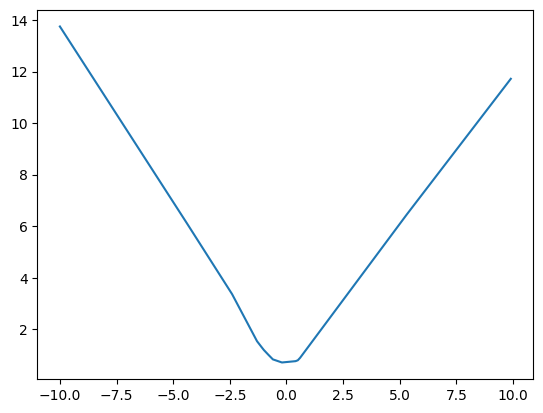

In [17]:
torch_range = torch.arange(-10,10,0.1).to(device)
y = net(torch_range.unsqueeze(1))
plt.plot(torch_range.detach().cpu().numpy(),y.detach().cpu().numpy())

In [10]:
import torch
torch.rand(10)*4 -2

tensor([ 0.0021,  1.7011, -0.1661,  1.6398,  0.3711, -0.2457, -1.3638, -0.1040,
        -1.3943,  1.0561])

In [7]:
import torch
from torch import nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

# Define simple model
YourModel = nn.Linear(10, 1)
def criterion(output, target):
    # simple MSE loss
    return torch.mean((output - target)**2)
inputs = torch.randn(100, 10)
targets = torch.randn(100, 1)
# Define your model, optimizer, and loss function
model = YourModel
optimizer = optim.SGD(model.parameters(), lr=0.1)
num_epochs = 100
# Define the learning rate scheduler
scheduler = lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)

# Training loop
for epoch in range(num_epochs):
    # Training code here
    
    # Perform a forward pass, compute loss, and update model parameters
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()

    # Update the learning rate
    scheduler.step()

    # Print the current learning rate
    print("Epoch:", epoch, "Learning Rate:", scheduler.get_last_lr()[0])


Epoch: 0 Learning Rate: 0.1
Epoch: 1 Learning Rate: 0.1
Epoch: 2 Learning Rate: 0.1
Epoch: 3 Learning Rate: 0.1
Epoch: 4 Learning Rate: 0.1
Epoch: 5 Learning Rate: 0.1
Epoch: 6 Learning Rate: 0.1
Epoch: 7 Learning Rate: 0.1
Epoch: 8 Learning Rate: 0.1
Epoch: 9 Learning Rate: 0.1
Epoch: 10 Learning Rate: 0.1
Epoch: 11 Learning Rate: 0.1
Epoch: 12 Learning Rate: 0.1
Epoch: 13 Learning Rate: 0.1
Epoch: 14 Learning Rate: 0.1
Epoch: 15 Learning Rate: 0.1
Epoch: 16 Learning Rate: 0.1
Epoch: 17 Learning Rate: 0.1
Epoch: 18 Learning Rate: 0.1
Epoch: 19 Learning Rate: 0.1
Epoch: 20 Learning Rate: 0.1
Epoch: 21 Learning Rate: 0.1
Epoch: 22 Learning Rate: 0.1
Epoch: 23 Learning Rate: 0.1
Epoch: 24 Learning Rate: 0.1
Epoch: 25 Learning Rate: 0.1
Epoch: 26 Learning Rate: 0.1
Epoch: 27 Learning Rate: 0.1
Epoch: 28 Learning Rate: 0.1
Epoch: 29 Learning Rate: 0.1
Epoch: 30 Learning Rate: 0.1
Epoch: 31 Learning Rate: 0.1
Epoch: 32 Learning Rate: 0.1
Epoch: 33 Learning Rate: 0.1
Epoch: 34 Learning Rate: